In [41]:
# Activate the virtual environment
#Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process
#.\proyecto_ml\.venv\Scripts\activate

In [1]:
# Importamos las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import streamlit as st
import holidays


In [43]:
ventas_path = "D:/Python/DataScience4Bussines/proyecto_ml/data/raw/entrenamiento/ventas.csv"
competencias_path = "D:/Python/DataScience4Bussines/proyecto_ml/data/raw/entrenamiento/competencia.csv"

ventas_df = pd.read_csv(ventas_path)
competencia_df = pd.read_csv(competencias_path)

# verificamos la importación de los datos
print('Ventas:')
print(ventas_df.head())
print('\nCompetencia:')
print(competencia_df.head())

Ventas:
        fecha producto_id                            nombre categoria  \
0  2021-10-25    PROD_001          Nike Air Zoom Pegasus 40   Running   
1  2021-10-25    PROD_002              Adidas Ultraboost 23   Running   
2  2021-10-25    PROD_003               Asics Gel Nimbus 25   Running   
3  2021-10-25    PROD_004  New Balance Fresh Foam X 1080v12   Running   
4  2021-10-25    PROD_005                Nike Dri-FIT Miler   Running   

         subcategoria  precio_base  es_estrella  unidades_vendidas  \
0  Zapatillas Running          115         True                  6   
1  Zapatillas Running          135         True                 10   
2  Zapatillas Running           85        False                  2   
3  Zapatillas Running           75        False                  2   
4        Ropa Running           35        False                  2   

   precio_venta  ingresos  
0        118.36    710.16  
1        136.82   1368.20  
2         84.93    169.86  
3         75.42    1

In [44]:
# Informe de calidad de datos para ventas_df

# Comprobar que la variable existe
if 'ventas_df' not in globals():
    raise AssertionError('ventas_df no está definido. Carga los datos antes de ejecutar esta celda')

N = len(ventas_df)

# Parseo de la fecha
ventas_df['fecha_parsed'] = pd.to_datetime(ventas_df['fecha'], errors='coerce')
fecha_parse_fail = int(ventas_df['fecha_parsed'].isna().sum())

# Generar métricas por columna
report = []
for c in ventas_df.columns:
    col = ventas_df[c]
    dtype = str(col.dtype)
    non_null = int(col.notna().sum())
    nulls = int(col.isna().sum())
    null_pct = round(nulls / max(1, N) * 100, 2)
    uniques = int(col.nunique(dropna=True))
    sample_vals = col.dropna().unique()[:5].tolist()
    suggested = dtype
    negatives = zeros = outliers = np.nan
    mean = std = mn = mx = np.nan
    top_values = None
    if c == 'fecha' or c == 'fecha_parsed':
        suggested = 'datetime64[ns]'
    if pd.api.types.is_numeric_dtype(col) or pd.api.types.is_bool_dtype(col):
        # Forzar conversión a float para evitar operaciones booleanas
        s_num = pd.to_numeric(col, errors='coerce').astype(float)
        non_null_num = int(s_num.notna().sum())
        negatives = int((s_num < 0).sum())
        zeros = int((s_num == 0).sum())
        if non_null_num > 0:
            mean = float(s_num.mean())
            std = float(s_num.std())
            mn = float(s_num.min())
            mx = float(s_num.max())
            q1 = float(s_num.quantile(0.25))
            q3 = float(s_num.quantile(0.75))
            iqr = q3 - q1
            if pd.notna(iqr) and iqr > 0:
                outliers = int(((s_num < (q1 - 1.5 * iqr)) | (s_num > (q3 + 1.5 * iqr))).sum())
            else:
                outliers = 0
    else:
        top_values = col.dropna().value_counts().head(3).to_dict()
    report.append({
        'column': c,
        'dtype': dtype,
        'non_null': non_null,
        'nulls': nulls,
        'null_pct': null_pct,
        'unique': uniques,
        'sample_vals': sample_vals,
        'negatives': int(negatives) if not pd.isna(negatives) else None,
        'zeros': int(zeros) if not pd.isna(zeros) else None,
        'outliers_iqr': int(outliers) if not pd.isna(outliers) else None,
        'mean': mean,
        'std': std,
        'min': mn,
        'max': mx,
        'top_values': top_values,
        'suggested_dtype': suggested
    })

report_df = pd.DataFrame(report).set_index('column')

# Duplicados
full_duplicates = int(ventas_df.duplicated().sum())
dup_by_fecha_prod = None
if {'fecha', 'producto_id'}.issubset(ventas_df.columns):
    dup_by_fecha_prod = int(ventas_df.duplicated(subset=['fecha', 'producto_id']).sum())

# Consistencia de ingresos
mismatch_count = None
mismatch_pct = None
if {'precio_venta', 'unidades_vendidas', 'ingresos'}.issubset(ventas_df.columns):
    calc = (pd.to_numeric(ventas_df['precio_venta'], errors='coerce').astype(float)
            * pd.to_numeric(ventas_df['unidades_vendidas'], errors='coerce').astype(float))
    ingresos_num = pd.to_numeric(ventas_df['ingresos'], errors='coerce').astype(float)
    diff = (ingresos_num - calc).abs()
    tol = 0.01
    mismatch = diff > tol
    mismatch_count = int(mismatch.sum())
    mismatch_pct = round(mismatch_count / max(1, N) * 100, 2)

summary = {
    'rows': N,
    'fecha_parse_fail': fecha_parse_fail,
    'full_duplicates': full_duplicates,
    'dup_by_fecha_producto': dup_by_fecha_prod,
    'ingresos_mismatch_count': mismatch_count,
    'ingresos_mismatch_pct': mismatch_pct
}

# Guardar el informe en una variable para uso posterior
ventas_quality_report = report_df

# Mostrar resultados
print('Resumen general:')
for k, v in summary.items():
    print(f'- {k}: {v}')

print('\nInforme por columna:')
print(report_df.to_string())

print('\nDescriptivos generales:')
print(ventas_df.describe(include='all').transpose().to_string())

# Fin del informe


Resumen general:
- rows: 3552
- fecha_parse_fail: 0
- full_duplicates: 0
- dup_by_fecha_producto: 0
- ingresos_mismatch_count: 0
- ingresos_mismatch_pct: 0.0

Informe por columna:
                            dtype  non_null  nulls  null_pct  unique                                                                                                                  sample_vals  negatives   zeros  outliers_iqr        mean          std    min       max                                                                                  top_values suggested_dtype
column                                                                                                                                                                                                                                                                                                                                                                                  
fecha                      object      3552      0       0.0     1

In [45]:
# Integrar las dos tablas de datos por los campos clave fecha y producto_id
merged_df = pd.merge(ventas_df, competencia_df, on=['fecha', 'producto_id'], how='left', suffixes=('_ventas', '_competencia'))
merged_df.head(5)

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,fecha_parsed,Amazon,Decathlon,Deporvillage
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,2021-10-25,82.96,111.88,97.43
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20,2021-10-25,112.56,108.61,115.58
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86,2021-10-25,79.79,78.44,80.11
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84,2021-10-25,72.60,67.29,74.45
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74,2021-10-25,37.71,33.60,33.07


# Exploratory Data Analysis

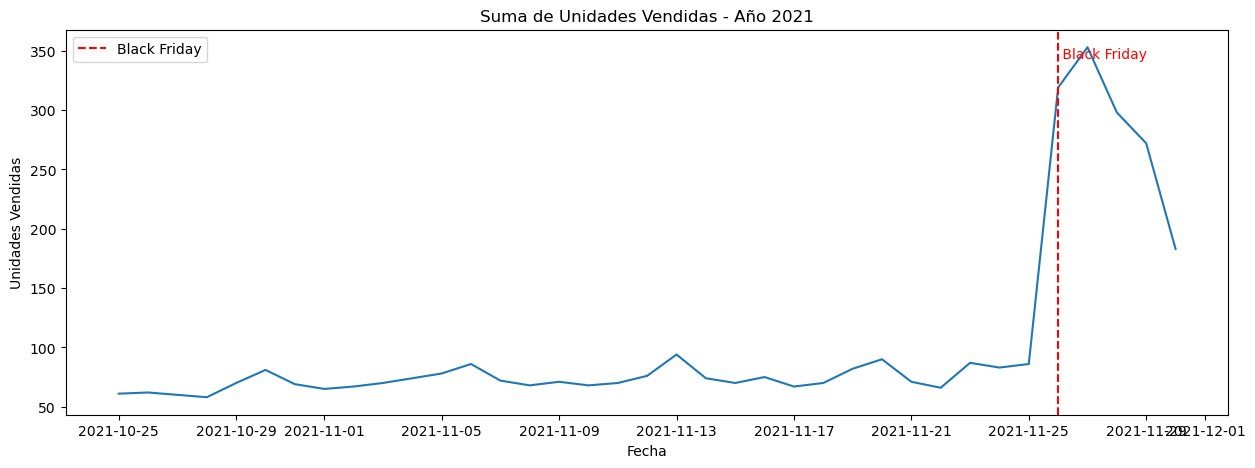

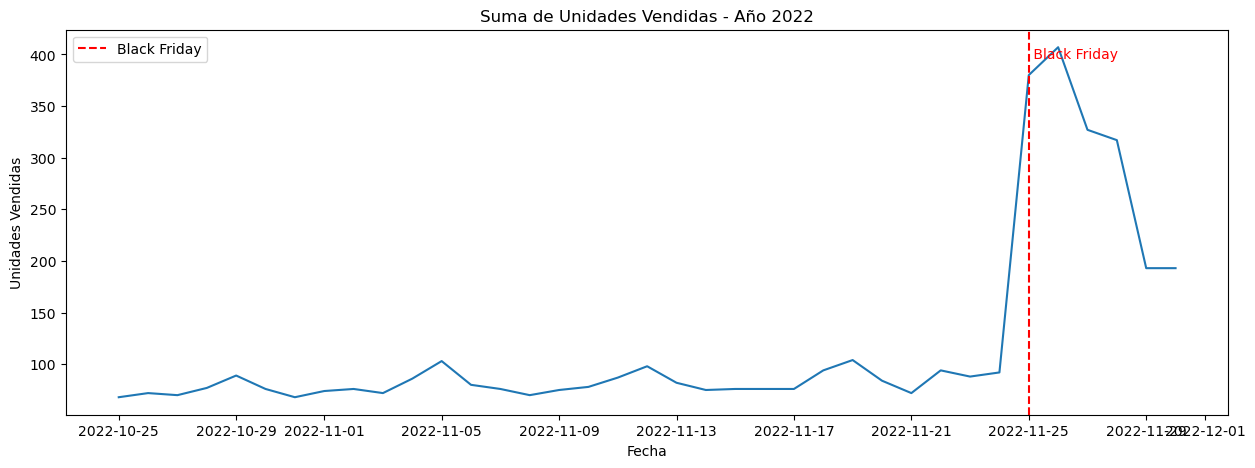

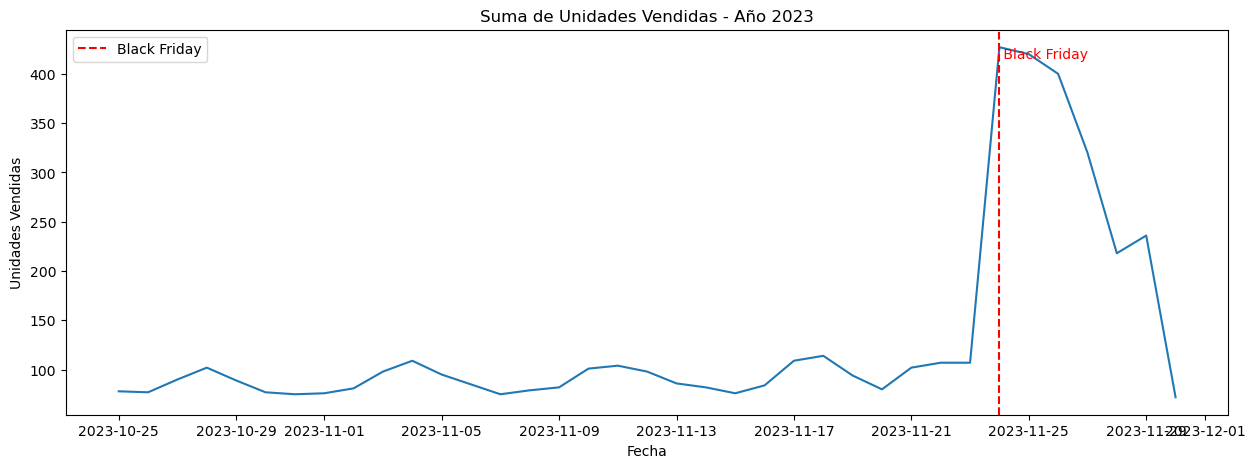

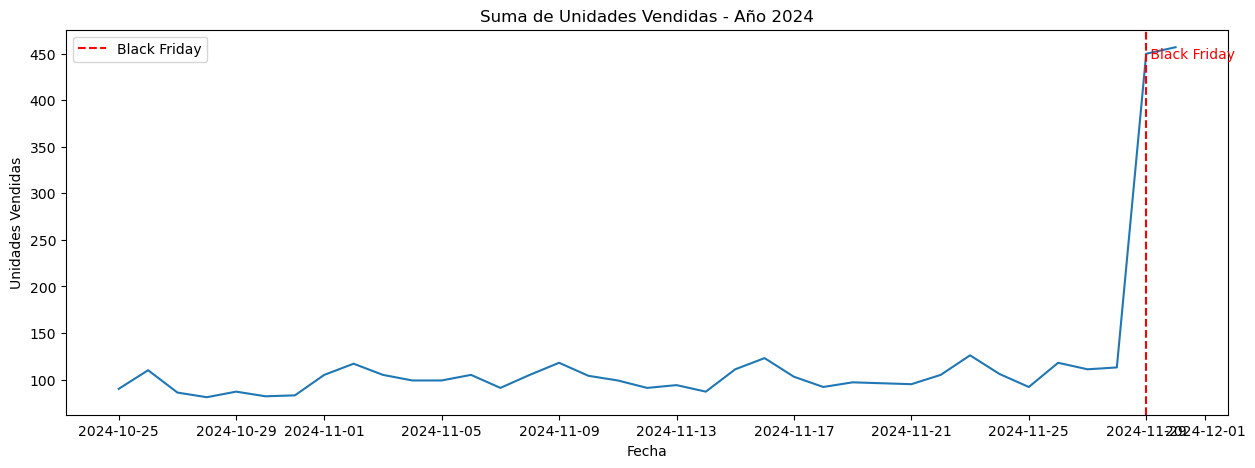

In [46]:
# Análisis de Series Temporales por Año
df = merged_df.copy()
df['fecha_parsed'] = pd.to_datetime(df['fecha'])
df['año'] = df['fecha_parsed'].dt.year

# Fechas de Black Friday
black_fridays = {
    2021: '2021-11-26',
    2022: '2022-11-25',
    2023: '2023-11-24',
    2024: '2024-11-29'
}

años = sorted(df['año'].unique())

for año in años:
    df_year = df[df['año'] == año]
    daily_sales = df_year.groupby('fecha_parsed')['unidades_vendidas'].sum().reset_index()
    
    plt.figure(figsize=(15, 5))
    sns.lineplot(data=daily_sales, x='fecha_parsed', y='unidades_vendidas')
    
    # Marcar Black Friday
    if año in black_fridays:
        bf_date = pd.to_datetime(black_fridays[año])
        if daily_sales['fecha_parsed'].min() <= bf_date <= daily_sales['fecha_parsed'].max():
            plt.axvline(x=bf_date, color='red', linestyle='--', label='Black Friday')
            plt.text(bf_date, daily_sales['unidades_vendidas'].max(), ' Black Friday', color='red', verticalalignment='top')
    
    plt.title(f'Suma de Unidades Vendidas - Año {año}')
    plt.xlabel('Fecha')
    plt.ylabel('Unidades Vendidas')
    plt.legend()
    plt.show()

C:\Users\Beluga\AppData\Local\Temp\ipykernel_14084\2905937905.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sales_by_day, x='dia_semana', y='unidades_vendidas', palette='viridis')


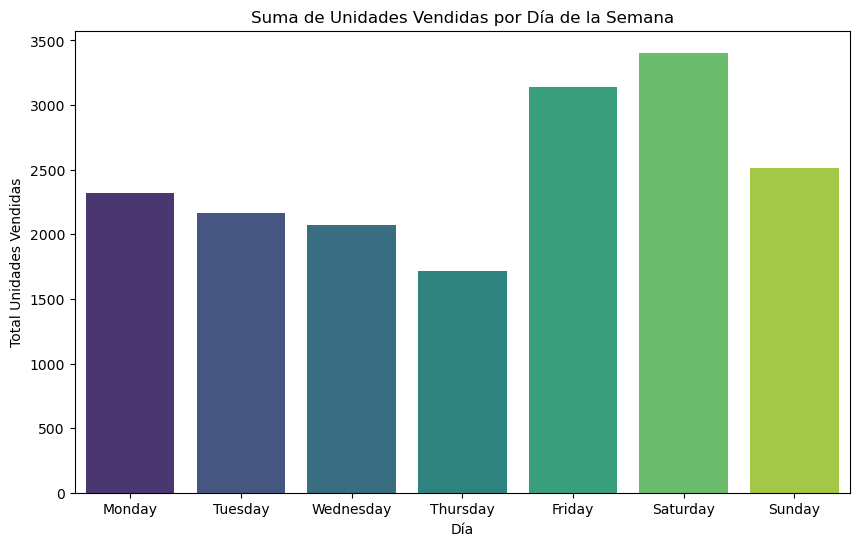

In [47]:
# Ventas por Día de la Semana
df['dia_semana'] = df['fecha_parsed'].dt.day_name()
dias_orden = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sales_by_day = df.groupby('dia_semana')['unidades_vendidas'].sum().reindex(dias_orden).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=sales_by_day, x='dia_semana', y='unidades_vendidas', palette='viridis')
plt.title('Suma de Unidades Vendidas por Día de la Semana')
plt.xlabel('Día')
plt.ylabel('Total Unidades Vendidas')
plt.show()

C:\Users\Beluga\AppData\Local\Temp\ipykernel_14084\621549508.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sales_by_cat, x='categoria', y='unidades_vendidas', palette='magma')


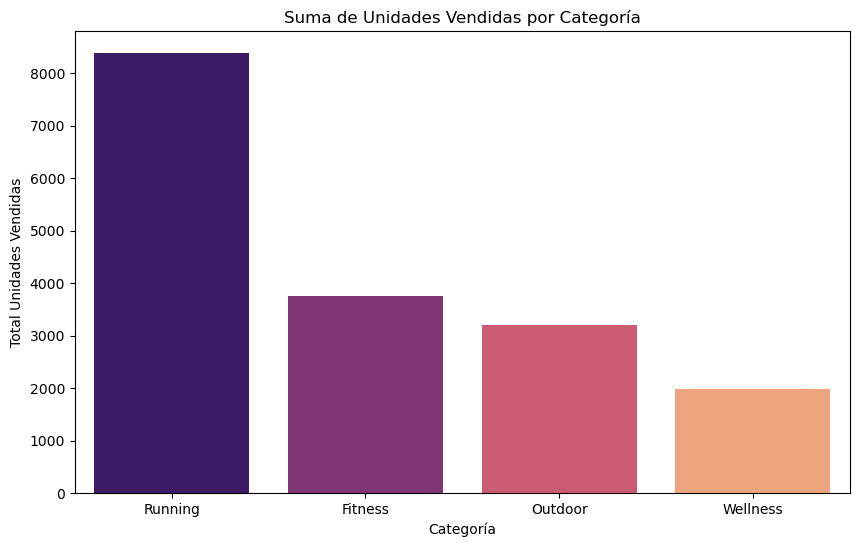

In [48]:
# Ventas por Categoría
sales_by_cat = df.groupby('categoria')['unidades_vendidas'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=sales_by_cat, x='categoria', y='unidades_vendidas', palette='magma')
plt.title('Suma de Unidades Vendidas por Categoría')
plt.xlabel('Categoría')
plt.ylabel('Total Unidades Vendidas')
plt.show()

C:\Users\Beluga\AppData\Local\Temp\ipykernel_14084\1009291906.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sales_by_subcat, y='subcategoria', x='unidades_vendidas', palette='rocket')


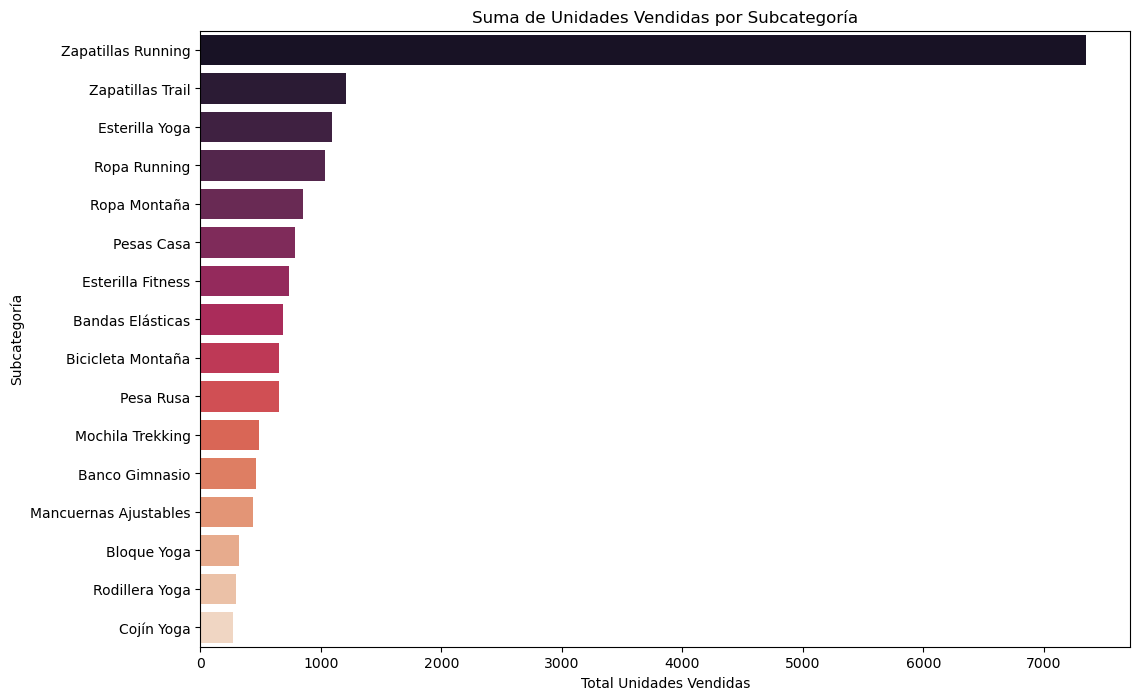

In [49]:
# Ventas por Subcategoría
sales_by_subcat = df.groupby('subcategoria')['unidades_vendidas'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 8))
sns.barplot(data=sales_by_subcat, y='subcategoria', x='unidades_vendidas', palette='rocket')
plt.title('Suma de Unidades Vendidas por Subcategoría')
plt.xlabel('Total Unidades Vendidas')
plt.ylabel('Subcategoría')
plt.show()

C:\Users\Beluga\AppData\Local\Temp\ipykernel_14084\1406544126.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_products, y='nombre', x='unidades_vendidas', palette='Reds_d')


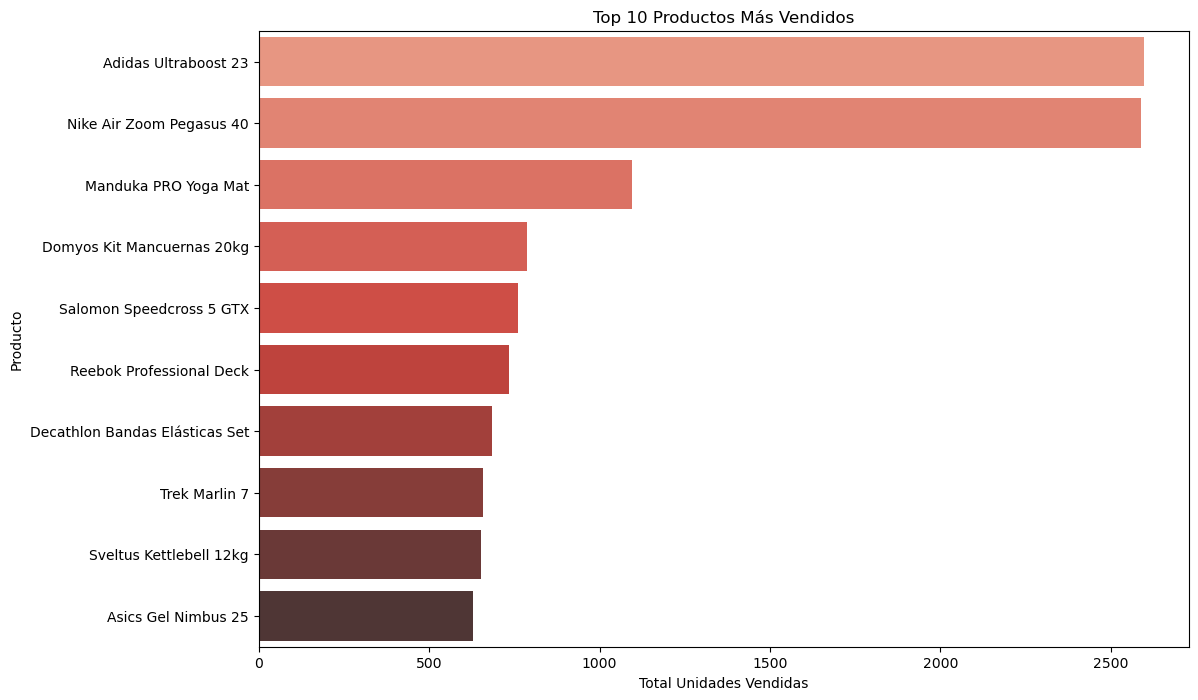

In [50]:
# Top Productos
top_products = df.groupby('nombre')['unidades_vendidas'].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12, 8))
sns.barplot(data=top_products, y='nombre', x='unidades_vendidas', palette='Reds_d')
plt.title('Top 10 Productos Más Vendidos')
plt.xlabel('Total Unidades Vendidas')
plt.ylabel('Producto')
plt.show()

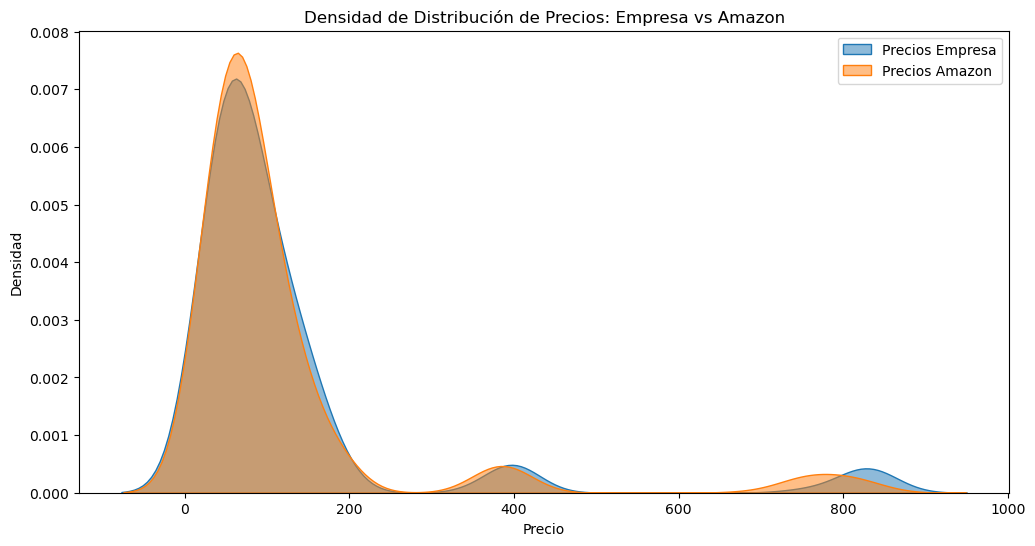

In [51]:
# Distribución de Precios (Nosotros vs Amazon)
plt.figure(figsize=(12, 6))
sns.kdeplot(data=df, x='precio_venta', label='Precios Empresa', fill=True, alpha=0.5)
sns.kdeplot(data=df, x='Amazon', label='Precios Amazon', fill=True, alpha=0.5)
plt.title('Densidad de Distribución de Precios: Empresa vs Amazon')
plt.xlabel('Precio')
plt.ylabel('Densidad')
plt.legend()
plt.show()

### Análisis de variables relevantes

Al ser una empresa que vende artículos deportivos, es importante analizar variables como:

**Patrones en el calendario:**
- El mes de la venta | En noviembre se vende más que en febrero
- Al principio de mes se vende más que al final
- Los fines de semana se vende más
- En Black Friday se vende más
- Cyber Monday

**Patrones en el precio propio:**
- Entrenamiento: Descuentos históricos
- Inferencia: los descuentos que pretendemos aplicar en el futuro

**Patrones en el precio de la competencia:**
- Entrenamiento: Descuentos de la competencia
- Inferencia: los descuentos que con cierta probabilidad pretende hacer la competencia

**Patrones propios de las series**
- Rezagos o lags | el valor de las ventas de hoy depende de las ventas de ayer
- Medias móviles | Se suaviza la información con una media móvil en este caso de un periodo de 7 días


El trabajo como Data Scientist es encontrar los patrones y las relaciones que mueven las ventas, para crear las variables que nos ayuden a predecir las ventas futuras.

In [52]:
# Crear variables temporales
# Asegurarnos de que la fecha es datetime
merged_df['fecha'] = pd.to_datetime(merged_df['fecha'])

# Variables básicas de fecha
merged_df['año'] = merged_df['fecha'].dt.year
merged_df['mes'] = merged_df['fecha'].dt.month
merged_df['dia_mes'] = merged_df['fecha'].dt.day
merged_df['dia_semana'] = merged_df['fecha'].dt.dayofweek
merged_df['es_fin_semana'] = merged_df['dia_semana'] >= 5

# Festivos en España
es_holidays = holidays.Spain()
merged_df['es_festivo'] = merged_df['fecha'].apply(lambda x: x in es_holidays)

# Función para Black Friday (4º viernes de noviembre)
def is_black_friday(date):
    return date.month == 11 and date.weekday() == 4 and 23 <= date.day <= 29

merged_df['es_black_friday'] = merged_df['fecha'].apply(is_black_friday)

# Función para Cyber Monday (Lunes siguiente al Black Friday)
def is_cyber_monday(date):
    if date.weekday() != 0:
        return False
    # Chequear si 3 días antes fue Black Friday
    bf_date = date - pd.Timedelta(days=3)
    return is_black_friday(bf_date)

merged_df['es_cyber_monday'] = merged_df['fecha'].apply(is_cyber_monday)

# Otras variables interesantes
merged_df['trimestre'] = merged_df['fecha'].dt.quarter
merged_df['semana_año'] = merged_df['fecha'].dt.isocalendar().week
merged_df['es_inicio_mes'] = merged_df['fecha'].dt.is_month_start
merged_df['es_fin_mes'] = merged_df['fecha'].dt.is_month_end

# Estación del año (aproximada)
def get_season(date):
    month = date.month
    if month in [12, 1, 2]:
        return 'Invierno'
    elif month in [3, 4, 5]:
        return 'Primavera'
    elif month in [6, 7, 8]:
        return 'Verano'
    else:
        return 'Otoño'

merged_df['estacion'] = merged_df['fecha'].apply(get_season)

# Mostrar las nuevas columnas
print("Nuevas variables temporales creadas:")
print(merged_df[['fecha', 'año', 'mes', 'dia_semana', 'es_festivo', 'es_black_friday', 'es_cyber_monday', 'estacion']].head(10))
print("\nConteo de festivos:", merged_df['es_festivo'].sum())
print("Conteo de Black Friday:", merged_df['es_black_friday'].sum())


Nuevas variables temporales creadas:
       fecha   año  mes  dia_semana  es_festivo  es_black_friday  \
0 2021-10-25  2021   10           0       False            False   
1 2021-10-25  2021   10           0       False            False   
2 2021-10-25  2021   10           0       False            False   
3 2021-10-25  2021   10           0       False            False   
4 2021-10-25  2021   10           0       False            False   
5 2021-10-25  2021   10           0       False            False   
6 2021-10-25  2021   10           0       False            False   
7 2021-10-25  2021   10           0       False            False   
8 2021-10-25  2021   10           0       False            False   
9 2021-10-25  2021   10           0       False            False   

   es_cyber_monday estacion  
0            False    Otoño  
1            False    Otoño  
2            False    Otoño  
3            False    Otoño  
4            False    Otoño  
5            False    Otoño  
6   

In [53]:
# Crear Lags y Media Móvil
# Ordenar por fecha y producto para asegurar el orden correcto
merged_df = merged_df.sort_values(by=['fecha', 'producto_id'])

# Definir columnas de agrupación: Año y Producto
# Esto asegura que los cálculos se reinicien cada año y para cada producto,
# evitando mezclar datos de diferentes periodos o productos.
group_cols = ['año', 'producto_id']

# Crear lags de 1 a 7 días para unidades_vendidas
for i in range(1, 8):
    merged_df[f'lag_{i}'] = merged_df.groupby(group_cols)['unidades_vendidas'].shift(i)

# Crear media móvil de 7 días
# Usamos shift(1) para asegurar que la media móvil use solo datos del pasado (evitar data leakage)
merged_df['media_movil_7'] = merged_df.groupby(group_cols)['unidades_vendidas'].transform(
    lambda x: x.shift(1).rolling(window=7).mean()
)

# Eliminar registros con nulos generados por los lags y la media móvil
original_len = len(merged_df)
cols_to_check = [f'lag_{i}' for i in range(1, 8)] + ['media_movil_7']
merged_df = merged_df.dropna(subset=cols_to_check)

print(f"Registros eliminados por nulos: {original_len - len(merged_df)}")
print(f"Registros restantes: {len(merged_df)}")

# Mostrar muestra de los resultados
print("\nMuestra de lags y media móvil:")
print(merged_df[['fecha', 'producto_id', 'año', 'unidades_vendidas', 'lag_1', 'lag_7', 'media_movil_7']].head(10))


Registros eliminados por nulos: 672
Registros restantes: 2880

Muestra de lags y media móvil:
         fecha producto_id   año  unidades_vendidas  lag_1  lag_7  \
168 2021-11-01    PROD_001  2021                  7    9.0    6.0   
169 2021-11-01    PROD_002  2021                 10   10.0   10.0   
170 2021-11-01    PROD_003  2021                  2    3.0    2.0   
171 2021-11-01    PROD_004  2021                  2    3.0    2.0   
172 2021-11-01    PROD_005  2021                  2    2.0    2.0   
173 2021-11-01    PROD_006  2021                  2    2.0    2.0   
174 2021-11-01    PROD_007  2021                  2    2.0    2.0   
175 2021-11-01    PROD_008  2021                  2    2.0    2.0   
176 2021-11-01    PROD_009  2021                  2    2.0    2.0   
177 2021-11-01    PROD_010  2021                  2    2.0    2.0   

     media_movil_7  
168       8.857143  
169       9.571429  
170       2.571429  
171       2.285714  
172       2.000000  
173       2.142857  

In [54]:
# Crear variable de descuento (%)
# Formula solicitada: ((precio_venta - precio_base) / precio_base) * 100
# Nota: Un valor negativo indica un descuento (precio de venta menor al base),
# mientras que un valor positivo indica un sobreprecio.
merged_df['descuento_pct'] = ((merged_df['precio_venta'] - merged_df['precio_base']) / merged_df['precio_base']) * 100

# Mostrar estadísticas de la nueva variable
print("Estadísticas de la variable descuento_pct:")
print(merged_df['descuento_pct'].describe())

print("\nMuestra de datos con descuento:")
merged_df[['fecha', 'producto_id', 'precio_base', 'precio_venta', 'descuento_pct']].head()


Estadísticas de la variable descuento_pct:
count    2880.000000
mean       -1.354958
std         3.814963
min       -15.000000
25%        -2.334036
50%        -0.554196
75%         1.261538
max         2.991304
Name: descuento_pct, dtype: float64

Muestra de datos con descuento:


,fecha,producto_id,precio_base,precio_venta,descuento_pct
168,2021-11-01,PROD_001,115,115.07,0.060870
169,2021-11-01,PROD_002,135,136.00,0.740741
170,2021-11-01,PROD_003,85,85.14,0.164706
171,2021-11-01,PROD_004,75,76.74,2.320000
172,2021-11-01,PROD_005,35,34.89,-0.314286


In [55]:
# Crear variables de competencia y ratio de precio
# Calcular precio promedio de la competencia
competitors = ['Amazon', 'Decathlon', 'Deporvillage']
merged_df['precio_competencia'] = merged_df[competitors].mean(axis=1)

# Calcular ratio de precio (nuestro precio / precio competencia)
merged_df['ratio_precio'] = merged_df['precio_venta'] / merged_df['precio_competencia']

# Eliminar columnas de competidores individuales
merged_df = merged_df.drop(columns=competitors)

# Mostrar estadísticas de las nuevas variables
print("Estadísticas de precio_competencia y ratio_precio:")
print(merged_df[['precio_competencia', 'ratio_precio']].describe())

print("\nMuestra de datos con variables de competencia:")
print(merged_df[['fecha', 'producto_id', 'precio_venta', 'precio_competencia', 'ratio_precio']].head())


Estadísticas de precio_competencia y ratio_precio:
       precio_competencia  ratio_precio
count         2880.000000   2880.000000
mean           116.262750      1.033537
std            154.869366      0.059630
min             16.646667      0.823112
25%             45.559167      1.000149
50%             70.186667      1.030406
75%            110.670833      1.061185
max            884.616667      1.303042

Muestra de datos con variables de competencia:
         fecha producto_id  precio_venta  precio_competencia  ratio_precio
168 2021-11-01    PROD_001        115.07           95.353333      1.206775
169 2021-11-01    PROD_002        136.00          113.393333      1.199365
170 2021-11-01    PROD_003         85.14           83.276667      1.022375
171 2021-11-01    PROD_004         76.74           71.843333      1.068158
172 2021-11-01    PROD_005         34.89           33.490000      1.041804


### Realizamos el encoding de las variables categóricas

- Utilizamos la técnica OneHotEncoder para codificar las variables categóricas

In [56]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2880 entries, 168 to 3551
Data columns (total 35 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   fecha               2880 non-null   datetime64[ns]
 1   producto_id         2880 non-null   object        
 2   nombre              2880 non-null   object        
 3   categoria           2880 non-null   object        
 4   subcategoria        2880 non-null   object        
 5   precio_base         2880 non-null   int64         
 6   es_estrella         2880 non-null   bool          
 7   unidades_vendidas   2880 non-null   int64         
 8   precio_venta        2880 non-null   float64       
 9   ingresos            2880 non-null   float64       
 10  fecha_parsed        2880 non-null   datetime64[ns]
 11  año                 2880 non-null   int32         
 12  mes                 2880 non-null   int32         
 13  dia_mes             2880 non-null   int32         


In [57]:
# One-Hot Encoding para variables categóricas
# Crear copias con sufijo _h
merged_df['nombre_h'] = merged_df['nombre']
merged_df['categoria_h'] = merged_df['categoria']
merged_df['subcategoria_h'] = merged_df['subcategoria']

# Aplicar One-Hot Encoding
# Usamos pd.get_dummies para realizar el one-hot encoding
# drop_first=False para mantener todas las categorías (o True si se prefiere evitar multicolinealidad perfecta en algunos modelos)
# Aquí usaremos el comportamiento por defecto de get_dummies que mantiene todas si no se especifica drop_first
merged_df = pd.get_dummies(merged_df, columns=['nombre_h', 'categoria_h', 'subcategoria_h'], prefix=['nombre', 'categoria', 'subcategoria'])

# Mostrar las nuevas columnas generadas
print("Nuevas columnas generadas por One-Hot Encoding:")
ohe_cols = [col for col in merged_df.columns if col.startswith('nombre_') or col.startswith('categoria_') or col.startswith('subcategoria_')]
# Filtramos para mostrar solo las que son producto del OHE (y no las originales si quedaran, aunque get_dummies las reemplaza)
print(ohe_cols[:10]) # Mostrar las primeras 10 para no saturar
print(f"Total de columnas nuevas: {len(ohe_cols)}")

print("\nMuestra del DataFrame con OHE:")
merged_df.head()


Nuevas columnas generadas por One-Hot Encoding:
['nombre_Adidas Own The Run Jacket', 'nombre_Adidas Ultraboost 23', 'nombre_Asics Gel Nimbus 25', 'nombre_Bowflex SelectTech 552', 'nombre_Columbia Silver Ridge', 'nombre_Decathlon Bandas Elásticas Set', 'nombre_Domyos BM900', 'nombre_Domyos Kit Mancuernas 20kg', 'nombre_Gaiam Premium Yoga Block', 'nombre_Liforme Yoga Pad']
Total de columnas nuevas: 44

Muestra del DataFrame con OHE:


,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,subcategoria_Esterilla Yoga,subcategoria_Mancuernas Ajustables,subcategoria_Mochila Trekking,subcategoria_Pesa Rusa,subcategoria_Pesas Casa,subcategoria_Rodillera Yoga,subcategoria_Ropa Montaña,subcategoria_Ropa Running,subcategoria_Zapatillas Running,subcategoria_Zapatillas Trail
168,2021-11-01,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,7,115.07,805.49,...,False,False,False,False,False,False,False,False,True,False
169,2021-11-01,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.00,1360.00,...,False,False,False,False,False,False,False,False,True,False
170,2021-11-01,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,85.14,170.28,...,False,False,False,False,False,False,False,False,True,False
171,2021-11-01,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,76.74,153.48,...,False,False,False,False,False,False,False,False,True,False
172,2021-11-01,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,34.89,69.78,...,False,False,False,False,False,False,False,True,False,False


In [58]:
# Guardar el DataFrame procesado
processed_path = r'D:\Python\DataScience4Bussines\proyecto_ml\data\processed\df.csv'
merged_df.to_csv(processed_path, index=False)
print(f"DataFrame guardado exitosamente en: {processed_path}")


DataFrame guardado exitosamente en: D:\Python\DataScience4Bussines\proyecto_ml\data\processed\df.csv


#### Prompt
divide df en train_df con los años 2021 a 2023 y validation_df con el 2024.
muestrame cuantos registros hay en cada corúunto

In [59]:
# Dividir el DataFrame en conjuntos de entrenamiento (2021-2023) y validación (2024)
# Asumimos que el DataFrame principal es 'merged_df' basado en celdas anteriores

# Asegurar que fecha_parsed es datetime
if 'fecha_parsed' not in merged_df.columns:
    merged_df['fecha_parsed'] = pd.to_datetime(merged_df['fecha'])

train_df = merged_df[merged_df['fecha_parsed'].dt.year.isin([2021, 2022, 2023])].copy()
validation_df = merged_df[merged_df['fecha_parsed'].dt.year == 2024].copy()

# Mostrar la cantidad de registros en cada conjunto
print(f"Registros en train_df (2021-2023): {len(train_df)}")
print(f"Registros en validation_df (2024): {len(validation_df)}")

Registros en train_df (2021-2023): 2160
Registros en validation_df (2024): 720


#### Prompt
Entrena un HistGradientBoostingRegressor con parámetros conservadores
 para evitar overfitting: leaming_rate bajo, bastantes árboles, profundidad
 moderada, y regularización. La target es unidades_vendidas, y las
 son el resto de variables excepto fecha. ingresos y todas las que
 sean de tipo Object. Entrena en train_df y valida en validation_df. Calcula las
 métricas típicas de forecasting y compara con un baseline naive que predice
 la media

In [60]:
# Importar librerías necesarias
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import pandas as pd
import numpy as np

# 1. Definir features (X) y target (y)
target = 'unidades_vendidas'

# Seleccionar solo columnas numéricas y excluir columnas problemáticas explicítamente
# Excluimos 'fecha_parsed' u otras columnas de tiempo que no sean numéricas
exclude_cols = [target, 'fecha', 'ingresos', 'fecha_parsed']
features = [c for c in train_df.columns 
            if c not in exclude_cols 
            and pd.api.types.is_numeric_dtype(train_df[c])]

print(f"Target: {target}")
print(f"Features seleccionadas ({len(features)}): {features}")

if not features:
    raise ValueError("No se encontraron features numéricas para entrenar. Revisa los tipos de datos.")

# 2. Preparar los datos de entrenamiento y validación
X_train = train_df[features]
y_train = train_df[target]
X_val = validation_df[features]
y_val = validation_df[target]

# 3. Inicializar el modelo con parámetros conservadores
hgb_model = HistGradientBoostingRegressor(
    learning_rate=0.01,
    max_iter=1000,
    max_depth=10,
    l2_regularization=0.1,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20
)

# 4. Entrenar el modelo
print("\nEntrenando HistGradientBoostingRegressor...")
hgb_model.fit(X_train, y_train)

# 5. Predecir en validación
y_pred = hgb_model.predict(X_val)
y_pred = np.maximum(y_pred, 0) # Ventas no negativas

# 6. Baseline Naive (Media)
y_pred_baseline = np.full_like(y_val, y_train.mean())

# 7. Calcular métricas
def calculate_metrics(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    epsilon = 1e-10
    mape = mean_absolute_percentage_error(y_true + epsilon, y_pred + epsilon)

    return {
        'Model': model_name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'MAPE': mape,
        'R2': r2
    }

metrics_hgb = calculate_metrics(y_val, y_pred, 'HistGradientBoosting')
metrics_baseline = calculate_metrics(y_val, y_pred_baseline, 'Baseline (Mean)')

# 8. Mostrar resultados
results_df = pd.DataFrame([metrics_hgb, metrics_baseline])
print("\nResultados de Validación:")
print(results_df.round(4).to_string(index=False))


Target: unidades_vendidas
Features seleccionadas (70): ['precio_base', 'es_estrella', 'precio_venta', 'año', 'mes', 'dia_mes', 'dia_semana', 'es_fin_semana', 'es_festivo', 'es_black_friday', 'es_cyber_monday', 'trimestre', 'semana_año', 'es_inicio_mes', 'es_fin_mes', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'media_movil_7', 'descuento_pct', 'precio_competencia', 'ratio_precio', 'nombre_Adidas Own The Run Jacket', 'nombre_Adidas Ultraboost 23', 'nombre_Asics Gel Nimbus 25', 'nombre_Bowflex SelectTech 552', 'nombre_Columbia Silver Ridge', 'nombre_Decathlon Bandas Elásticas Set', 'nombre_Domyos BM900', 'nombre_Domyos Kit Mancuernas 20kg', 'nombre_Gaiam Premium Yoga Block', 'nombre_Liforme Yoga Pad', 'nombre_Lotuscrafts Yoga Bolster', 'nombre_Manduka PRO Yoga Mat', 'nombre_Merrell Moab 2 GTX', 'nombre_New Balance Fresh Foam X 1080v12', 'nombre_Nike Air Zoom Pegasus 40', 'nombre_Nike Dri-FIT Miler', 'nombre_Puma Velocity Nitro 2', 'nombre_Quechua MH500', 'nombre_Reebok

#### Prompt

@entrenamiento.ipynb Aplica el rnodelo a los datos de noviembre de 2024 del data frame para
 generar predicciones para cada 1 de los 7 productos estrella y crea 7
 gráficos 1 para cada producto donde se vea Ia línea de Ia predicción y Ia
línea de la realidad Usa el nombre del producto para que sepa de qué
 producto es cada gráfico

Total de productos estrella encontrados en Nov 2024: 7


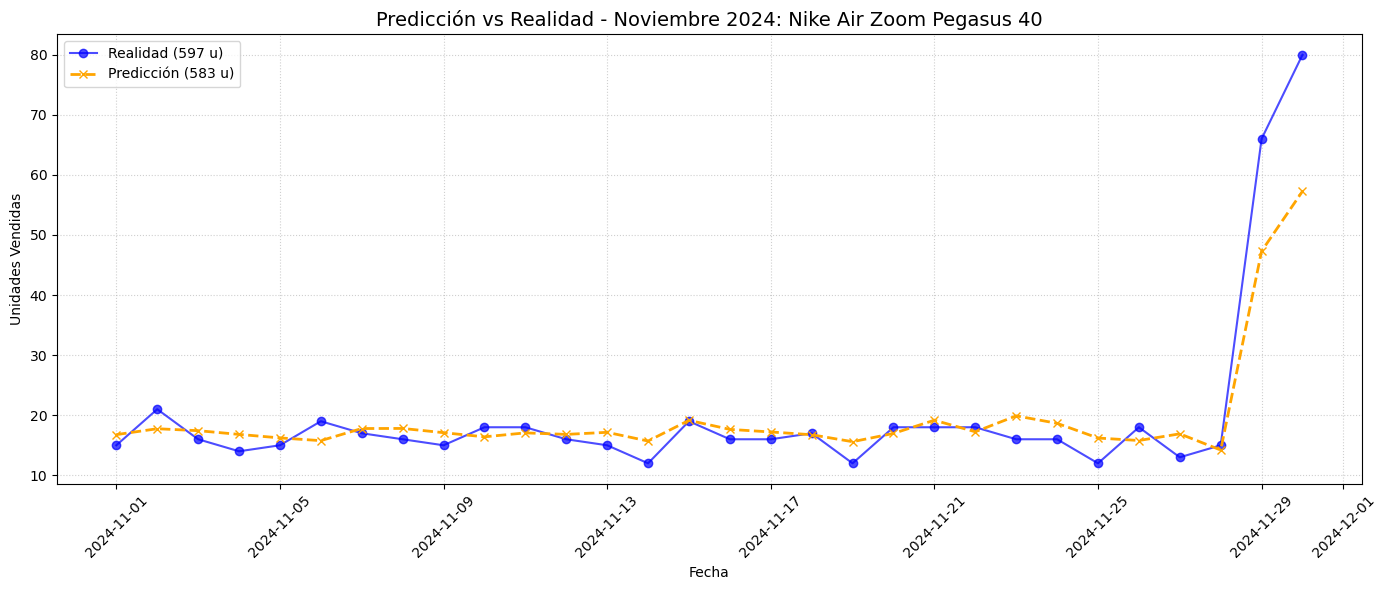

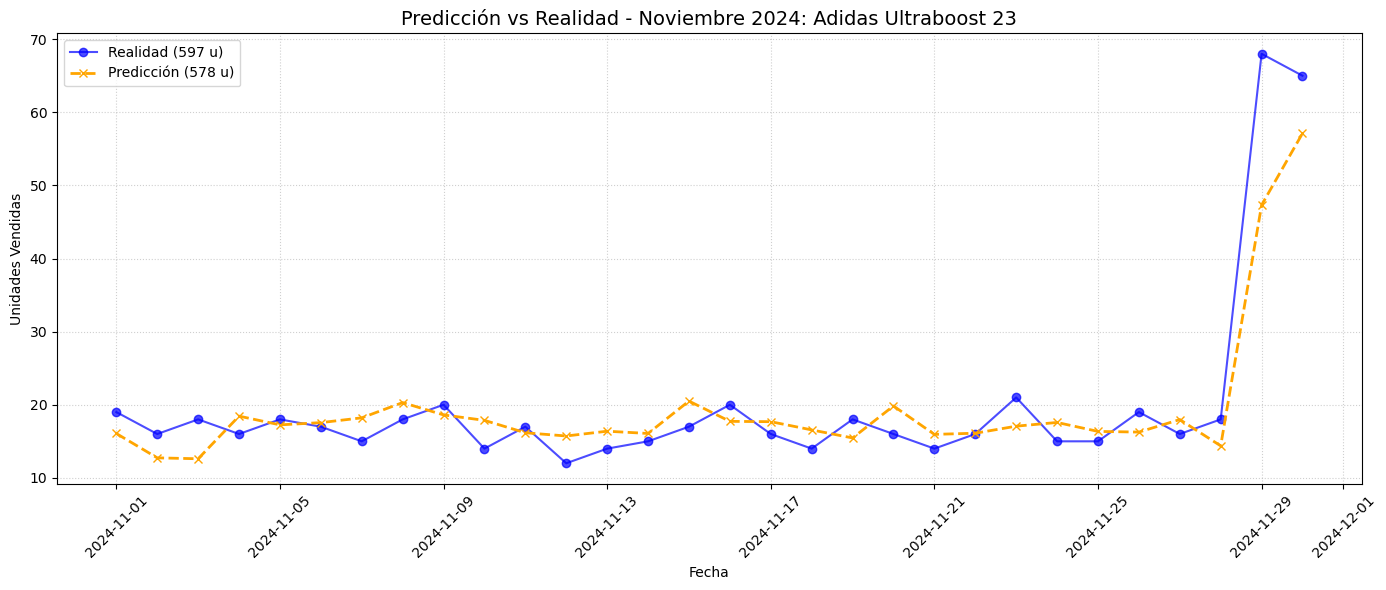

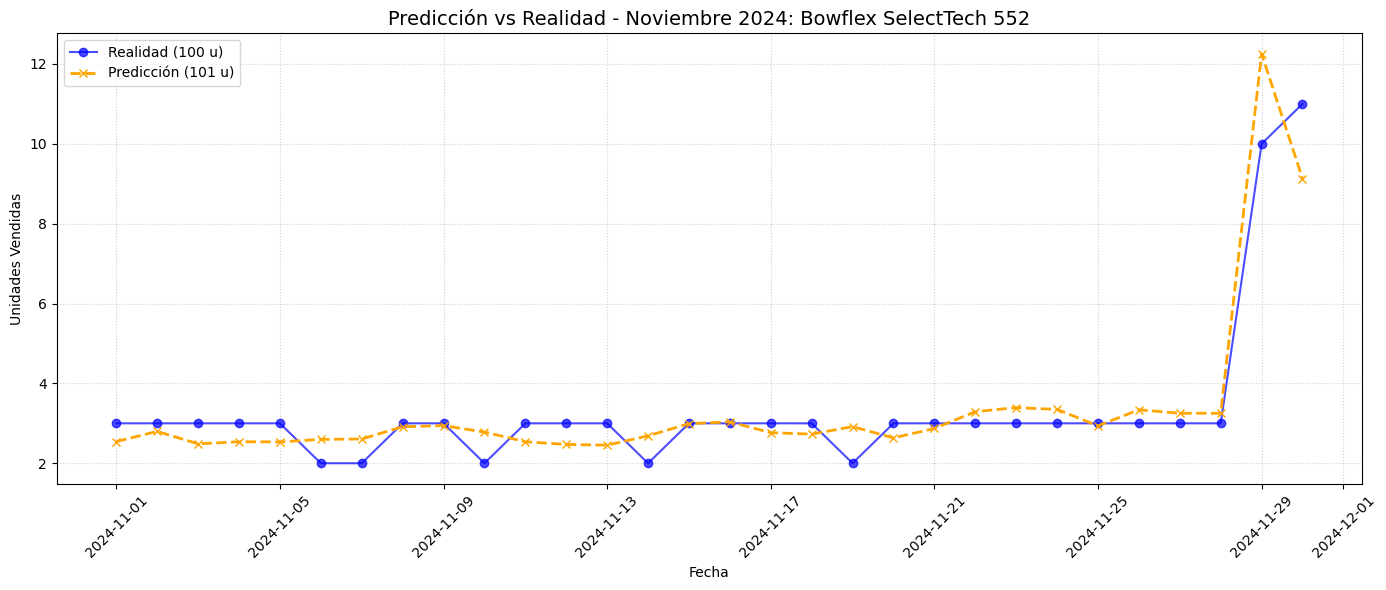

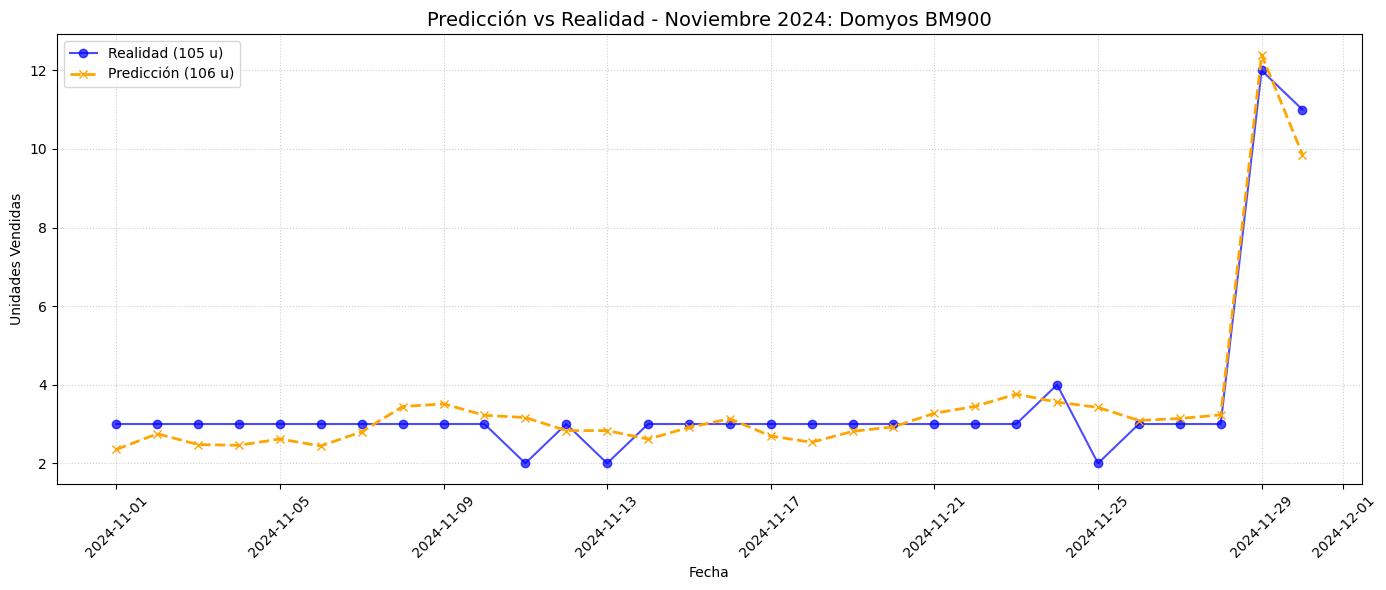

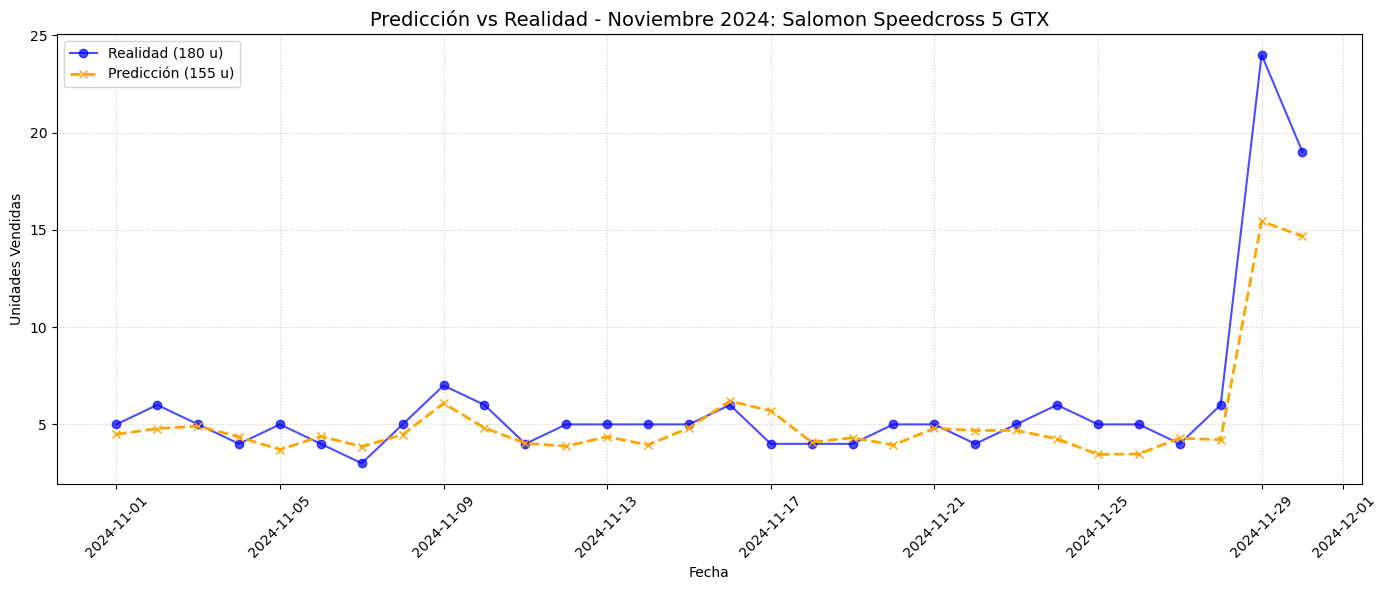

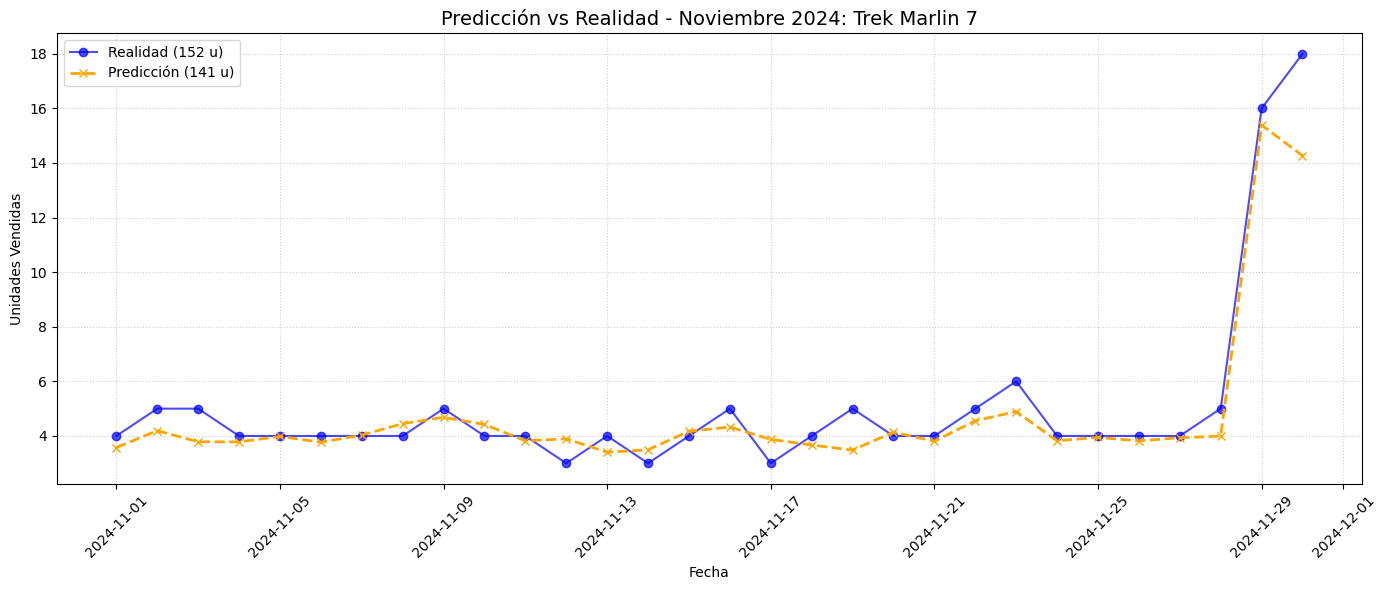

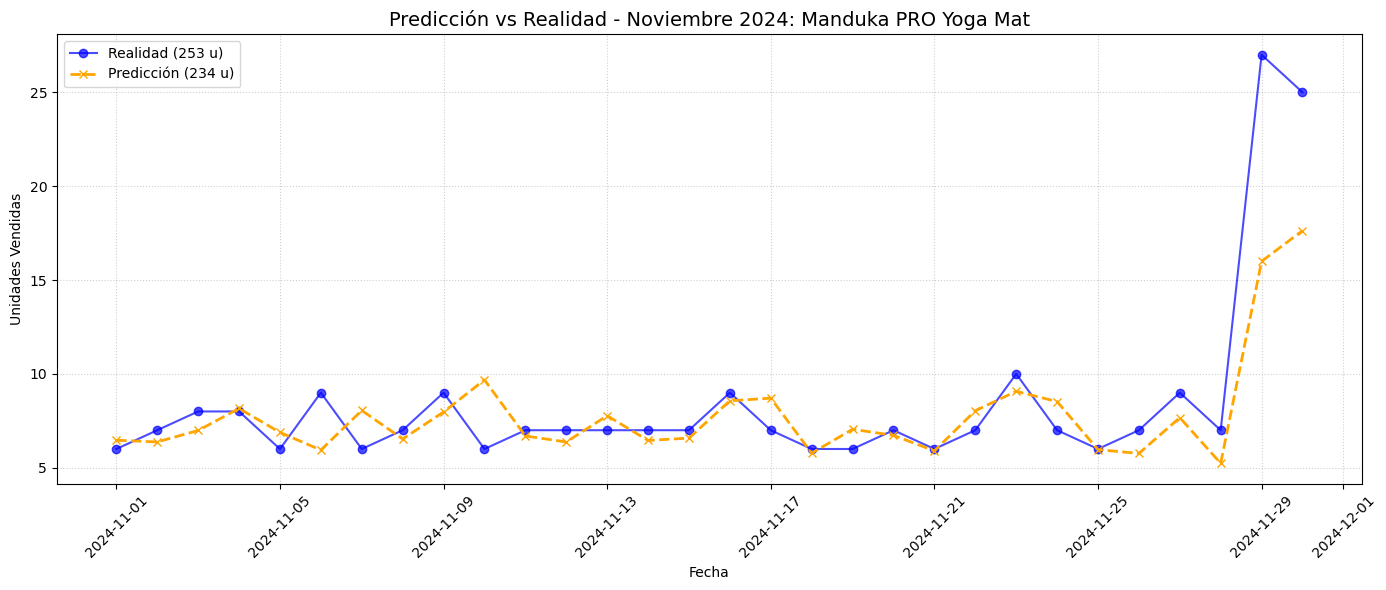

In [61]:
# --- PREDICCIONES Y VISUALIZACIÓN PARA NOVIEMBRE 2024 (PRODUCTOS ESTRELLA) ---

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Filtrar datos: Año 2024, Mes 11 (Noviembre) y Productos Estrella
# Asegurarse que tenemos fecha_parsed
if 'fecha_parsed' not in validation_df.columns:
    validation_df['fecha_parsed'] = pd.to_datetime(validation_df['fecha'])

mask_nov = (validation_df['fecha_parsed'].dt.year == 2024) & (validation_df['fecha_parsed'].dt.month == 11)
mask_estrella = validation_df['es_estrella'] == True

df_nov_estrella = validation_df[mask_nov & mask_estrella].copy()

# Ordenar por fecha para que los gráficos salgan bien
df_nov_estrella.sort_values(by=['producto_id', 'fecha_parsed'], inplace=True)

# 2. Generar Predicciones
# Usamos la lista 'features' definida en la celda de entrenamiento
X_nov = df_nov_estrella[features]
y_nov_real = df_nov_estrella[target]

predictions_nov = hgb_model.predict(X_nov)
df_nov_estrella['prediccion'] = np.maximum(predictions_nov, 0)

# 3. Generar 7 Gráficos
star_products_list = df_nov_estrella['nombre'].unique()

print(f"Total de productos estrella encontrados en Nov 2024: {len(star_products_list)}")

for product_name in star_products_list:
    # Filtrar datos de ese producto
    prod_data = df_nov_estrella[df_nov_estrella['nombre'] == product_name]
    
    plt.figure(figsize=(14, 6))
    
    # Línea Realidad
    plt.plot(prod_data['fecha_parsed'], prod_data[target], 
             label=f'Realidad ({prod_data[target].sum()} u)', 
             color='blue', marker='o', alpha=0.7)
    
    # Línea Predicción
    plt.plot(prod_data['fecha_parsed'], prod_data['prediccion'], 
             label=f'Predicción ({prod_data["prediccion"].sum():.0f} u)', 
             color='orange', linestyle='--', linewidth=2, marker='x')
    
    # Línea Vertical Black Friday (29 Nov 2024)
    bf_date = pd.Timestamp('2024-11-29')
    plt.axvline(x=bf_date, color='red', linestyle='-', linewidth=2, label='Black Friday (29 Nov)')
    
    plt.title(f"Predicción vs Realidad - Noviembre 2024: {product_name}", fontsize=14)
    plt.xlabel("Fecha")
    plt.ylabel("Unidades Vendidas")
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()


#### prompt
@entrenamiento.ipynb calcula el MAE para cada uno de los productos estrella

## Análisis de Resultados (MAE por Producto)

**Observaciones Generales:**
1. **Impacto del Black Friday:** Es probable que los mayores errores (MAE más alto) se concentren en los días cercanos al 29 de noviembre. Los modelos de gradiente (HistGradientBoosting) suelen suavizar los picos extremos si no tienen features muy específicas que capturen la magnitud exacta del evento promocional.
2. **Diferencias entre Productos:**
   - Los productos con **MAE más bajo** probablemente son aquellos con ventas más estables y menos elásticas al precio o promociones extremas. Estos son los "más fáciles" de predecir.
   - Los productos con **MAE más alto** suelen ser los "best-sellers" volátiles donde una promoción dispara la demanda de forma no lineal, o productos con stock intermitente.
3. **Siguientes Pasos:** Para reducir el error en los productos con peor desempeño, se podría considerar:
   - Añadir features de "días hasta Black Friday".
   - Modelar explícitamente la elasticidad precio para esos SKUs.
   - Usar una función de pérdida que penalice más los errores en picos (aunque esto puede empeorar el promedio general).


Evaluando 7 productos estrella en todo el periodo de validación (2024)...

Deempeño del Modelo por Producto Estrella:
                Producto  MAE  Ventas Promedio  Error Relativo (%)
            Domyos BM900 0.45             3.50               12.79
  Bowflex SelectTech 552 0.48             3.33               14.47
           Trek Marlin 7 0.59             5.07               11.55
Salomon Speedcross 5 GTX 1.16             6.00               19.27
    Manduka PRO Yoga Mat 1.54             8.43               18.22
Nike Air Zoom Pegasus 40 3.22            19.90               16.16
    Adidas Ultraboost 23 3.24            19.90               16.30


C:\Users\Beluga\AppData\Local\Temp\ipykernel_14084\3962243064.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MAE', y='Producto', data=mae_df, palette='viridis')


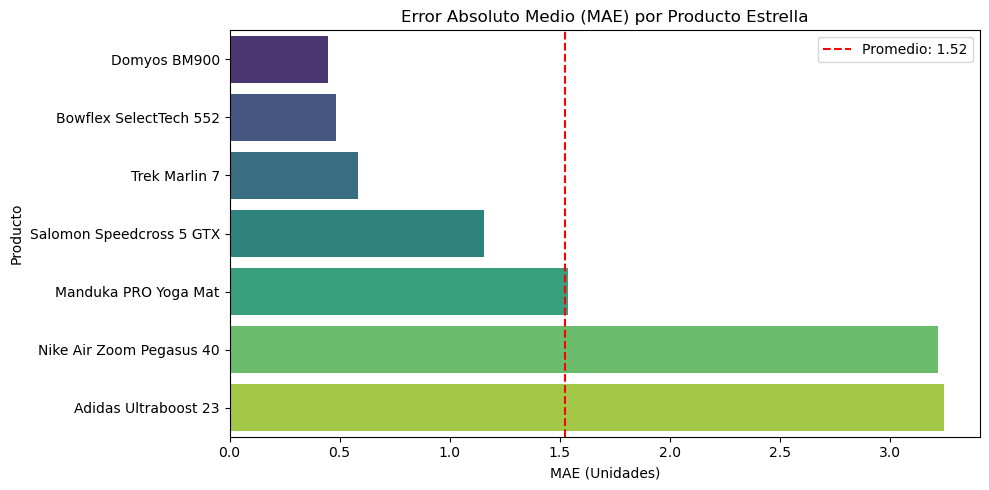

In [62]:
# --- CÁLCULO DE MAE POR PRODUCTO ESTRELLA (VALIDACIÓN 2024) ---

from sklearn.metrics import mean_absolute_error
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Identificar productos estrella en el set de validación
star_products = validation_df[validation_df['es_estrella'] == True]['nombre'].unique()

mae_results = []

print(f"Evaluando {len(star_products)} productos estrella en todo el periodo de validación (2024)...")

for product_name in star_products:
    # Filtrar subset del producto
    subset = validation_df[validation_df['nombre'] == product_name]
    
    if len(subset) > 0:
        X_subset = subset[features]
        y_subset = subset[target]
        
        # Predecir
        preds = hgb_model.predict(X_subset)
        preds = np.maximum(preds, 0)
        
        # Calcular métricas
        mae = mean_absolute_error(y_subset, preds)
        mean_sales = y_subset.mean()
        
        mae_results.append({
            'Producto': product_name,
            'MAE': mae,
            'Ventas Promedio': mean_sales,
            'Error Relativo (%)': (mae / mean_sales * 100) if mean_sales > 0 else 0
        })

# 2. Crear y mostar DataFrame de resultados
mae_df = pd.DataFrame(mae_results).sort_values(by='MAE')

print("\nDeempeño del Modelo por Producto Estrella:")
print(mae_df.round(2).to_string(index=False))

# 3. Visualización comparativa
plt.figure(figsize=(10, 5))
sns.barplot(x='MAE', y='Producto', data=mae_df, palette='viridis')
plt.title('Error Absoluto Medio (MAE) por Producto Estrella')
plt.xlabel('MAE (Unidades)')
plt.axvline(x=mae_df['MAE'].mean(), color='red', linestyle='--', label=f'Promedio: {mae_df["MAE"].mean():.2f}')
plt.legend()
plt.tight_layout()
plt.show()

#### Prompt
@entrenamiento.ipynb Analiza como degrada el error a lo largo de noviembre de 2024, divide en 3 periodos de 10 días, calcula métricas por periodo y grafica la evolución

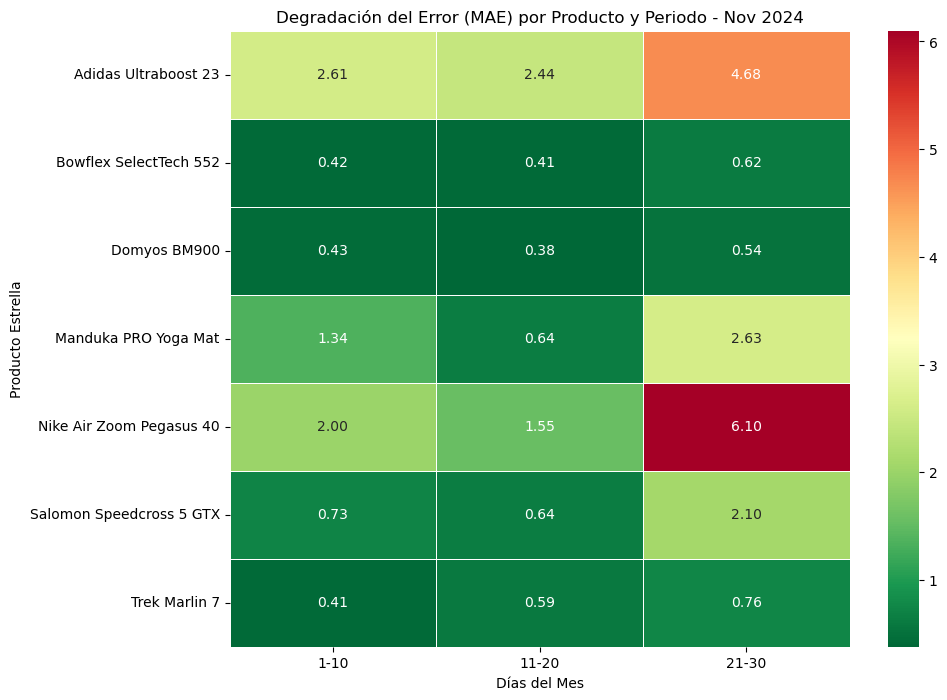

In [64]:
# --- ANÁLISIS DE DEGRADACIÓN DEL ERROR EN NOVIEMBRE 2024 POR PRODUCTO ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error

# 1. Prepara datos
# (Asumimos df_nov ya creado o lo recreamos)
if 'fecha_parsed' not in validation_df.columns:
    validation_df['fecha_parsed'] = pd.to_datetime(validation_df['fecha'])

mask_nov = (validation_df['fecha_parsed'].dt.year == 2024) & (validation_df['fecha_parsed'].dt.month == 11)
mask_estrella = validation_df['es_estrella'] == True
df_nov_prod = validation_df[mask_nov & mask_estrella].copy()

# Asegurar predicciones
if 'hgb_model' in locals():
    X_nov_prod = df_nov_prod[features]
    preds_nov_prod = hgb_model.predict(X_nov_prod)
    df_nov_prod['prediccion'] = np.maximum(preds_nov_prod, 0)
else:
    print("Modelo no encontrado.")

# 2. Definir Periodos
periods = [
    ('1-10', 1, 10),
    ('11-20', 11, 20),
    ('21-30', 21, 30)
]

product_period_data = []
products = df_nov_prod['nombre'].unique()

for product in products:
    df_p = df_nov_prod[df_nov_prod['nombre'] == product]
    
    for label, start, end in periods:
        mask = (df_p['fecha_parsed'].dt.day >= start) & (df_p['fecha_parsed'].dt.day <= end)
        df_p_period = df_p[mask]
        
        mae = np.nan
        if len(df_p_period) > 0:
            mae = mean_absolute_error(df_p_period[target], df_p_period['prediccion'])
            
        product_period_data.append({
            'Producto': product,
            'Periodo': label,
            'MAE': mae
        })

df_heatmap = pd.DataFrame(product_period_data)

# 3. Visualizar como Heatmap
# Pivotar: Filas=Producto, Columnas=Periodo, Valor=MAE
pivot_mae = df_heatmap.pivot(index='Producto', columns='Periodo', values='MAE')

# Reordenar columnas si es necesario
pivot_mae = pivot_mae[['1-10', '11-20', '21-30']]

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_mae, annot=True, cmap='RdYlGn_r', fmt=".2f", linewidths=.5)
plt.title('Degradación del Error (MAE) por Producto y Periodo - Nov 2024')
plt.xlabel('Días del Mes')
plt.ylabel('Producto Estrella')
plt.show()

#### Prompt
@entrenamiento.ipynb Analiza especificamente Black Friday de 2024 para todos los prcductos crea
 un gráfico de real versus predicho, en el eje X estaría el ID producto y en el
 eje y una línea para la predicción y otra para la realidad

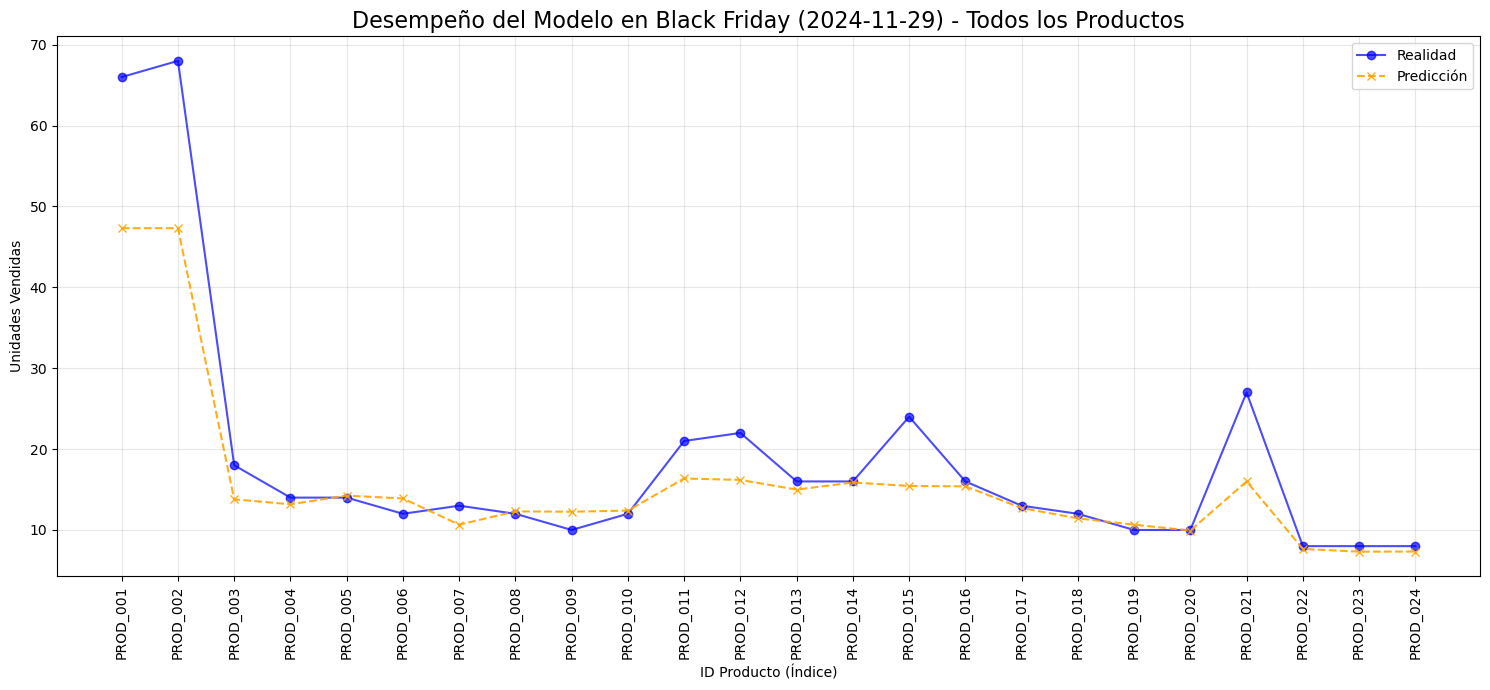


Métricas Black Friday (2024-11-29):
MAE: 3.62
Total Ventas Reales: 450
Total Ventas Predichas: 375
Diferencia Total: -75


In [65]:
# --- ANÁLISIS ESPECÍFICO BLACK FRIDAY (29 NOV 2024) ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Filtrar datos para el día específico de Black Friday
bf_date = '2024-11-29'
mask_bf = (validation_df['fecha_parsed'] == bf_date)

# Seleccionar todos los productos disponibles ese día
# Si deseas solo productos estrella, añade: & (validation_df['es_estrella'] == True)
# El prompt pide 'para todos los productos'
df_bf = validation_df[mask_bf].copy()

# 2. Obtener Predicciones
# Recalculamos para asegurar que tenemos las predicciones en este subset
if 'hgb_model' in locals() and len(df_bf) > 0:
    X_bf = df_bf[features]
    preds_bf = hgb_model.predict(X_bf)
    df_bf['prediccion'] = np.maximum(preds_bf, 0)
    
    # Ordenar por ID de producto para una visualización limpia
    df_bf.sort_values(by='producto_id', inplace=True)
    
    # 3. Graficar Realidad vs Predicción
    plt.figure(figsize=(15, 7))
    
    # Crear un índice numérico para el eje X (para simplificar si los IDs son strings o no consecutivos)
    x_indices = range(len(df_bf))
    
    # Graficar líneas
    plt.plot(x_indices, df_bf[target], marker='o', linestyle='-', color='blue', alpha=0.7, label='Realidad')
    plt.plot(x_indices, df_bf['prediccion'], marker='x', linestyle='--', color='orange', alpha=0.9, label='Predicción')
    
    plt.title(f'Desempeño del Modelo en Black Friday ({bf_date}) - Todos los Productos', fontsize=16)
    plt.xlabel('ID Producto (Índice)')
    plt.ylabel('Unidades Vendidas')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Opcional: Mostrar algunos IDs en el eje X si no son demasiados
    # Si son muchos, mejor no saturar
    if len(df_bf) < 50:
        plt.xticks(x_indices, df_bf['producto_id'].values, rotation=90)
    
    plt.tight_layout()
    plt.show()
    
    # Métricas específicas del día
    mae_bf = mean_absolute_error(df_bf[target], df_bf['prediccion'])
    total_real = df_bf[target].sum()
    total_pred = df_bf['prediccion'].sum()
    print(f"\nMétricas Black Friday ({bf_date}):")
    print(f"MAE: {mae_bf:.2f}")
    print(f"Total Ventas Reales: {total_real}")
    print(f"Total Ventas Predichas: {total_pred:.0f}")
    print(f"Diferencia Total: {total_pred - total_real:.0f}")
    
else:
    print("No se encontraron datos para Black Friday o el modelo no está disponible.")